[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/


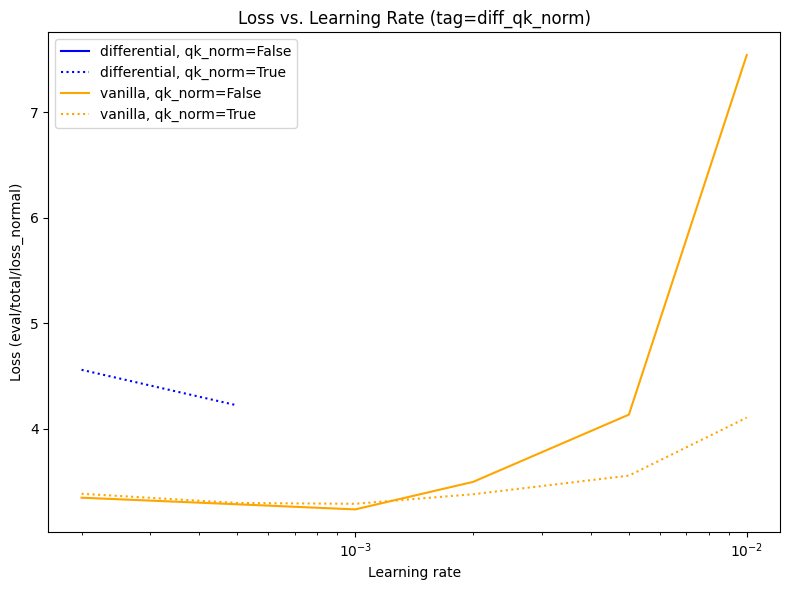

In [ ]:
import neptune
import pandas as pd
import matplotlib.pyplot as plt

# Initialize Neptune (make sure your API token and project are set, e.g. via environment variables)
# e.g. NEPTUNE_API_TOKEN and NEPTUNE_PROJECT
y_axis = "eval/total_loss/normal"
run_table = neptune.init_project(project="pmtest/llm-random").fetch_runs_table(
    tag=["diff_qk_norm"],
    columns=[
        "sys/id",
        "args/attention_mode",
        "args/use_qk_norm",
        "args/learning_rate",
        "eval/total_loss/normal",
        "args/dff",
    ],
)
plot_df = run_table.to_pandas()
plot_df = plot_df.sort_values(by=["args/attention_mode", "args/use_qk_norm", "args/learning_rate"])
plot_df.dropna(inplace=True)
# plot_df = plot_df[plot_df['args/dff'] == 2475]
plot_df = plot_df[plot_df['args/dff'] == 2048]

# Plot
plt.figure(figsize=(8, 6))
for att_mode, subdf in plot_df.groupby("args/attention_mode"):
    color = "blue" if att_mode == "differential" else "orange"
    for qk_norm, qdf in subdf.groupby("args/use_qk_norm"):
        linestyle = ":" if qk_norm else "-"
        plt.plot(
            qdf["args/learning_rate"].to_numpy(),
            qdf[y_axis].to_numpy(),
            linestyle=linestyle,
            marker='.',
            color=color,
            label=f"{att_mode}, qk_norm={qk_norm}",
        )

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Loss (eval/total/loss_normal)")
plt.title("Loss vs. Learning Rate (tag=diff_qk_norm)")
plt.legend()
plt.tight_layout()
plt.show()
